In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('/home/samri/climate-challenge-week0/data/nigeria.csv', encoding='latin1', skiprows=[1])
print(df.shape)
df.head()


(4107, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
1,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
2,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
3,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40
4,2015,6,22.66,25.77,18.03,7.74,0.0,62.57,1.37,2.10,101.00,10.61


In [3]:
df.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
4102,2026,86,29.05,32.43,26.69,5.74,2.82,76.60,2.35,3.39,100.58,19.10
4103,2026,87,28.72,31.98,27.14,4.84,5.19,79.61,2.55,3.17,100.64,19.49
4104,2026,88,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22
4105,2026,89,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73
4106,2026,90,28.40,31.73,26.32,5.41,5.33,78.79,1.76,2.80,100.59,18.94


In [4]:
df.sample(5)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
2921,2023,1,24.86,28.67,19.77,8.90,0.00,60.62,1.31,2.28,100.79,11.62
3651,2024,366,27.33,30.95,24.38,6.57,0.00,82.65,1.59,2.26,100.74,18.57
498,2016,135,27.11,28.31,26.23,2.08,14.42,91.35,2.88,3.79,100.84,20.48
3330,2024,45,28.78,31.93,26.29,5.64,0.26,86.16,2.41,3.36,100.81,21.14
133,2015,135,27.40,28.83,25.70,3.13,1.12,84.16,1.36,2.07,100.84,19.17


In [5]:
display(df.describe())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000
mean,2020.132700,180.164841,26.657275,28.914585,24.887149,4.027436,4.214940,85.241174,2.217253,2.903406,100.827197,18.559771
std,3.248315,106.270943,1.123251,1.294492,1.396200,1.398469,7.267329,5.440221,0.587213,0.696955,0.165341,1.644513
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000
25%,2017.000000,86.000000,25.720000,27.920000,24.105000,3.090000,0.330000,83.935000,1.770000,2.370000,100.710000,17.970000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000


Data Loading & Date Parsing

In [7]:
df["Country"] = "Nigeria"
# Create datetime column
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract month
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
1,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
2,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
3,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1
4,2015,6,22.66,25.77,18.03,7.74,0.0,62.57,1.37,2.10,101.00,10.61,Nigeria,2015-01-06,1


Handle Missing Values (-999)

In [8]:
df.replace(-999, np.nan, inplace=True)

Duplicate Check

In [9]:
duplicates = df.duplicated().sum()
duplicates

0

In [10]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107,4107.000000
mean,2020.132700,180.164841,26.657275,28.914585,24.887149,4.027436,4.214940,85.241174,2.217253,2.903406,100.827197,18.559771,2020-08-16 00:00:00,6.424884
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-02 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.105000,3.090000,0.330000,83.935000,1.770000,2.370000,100.710000,17.970000,2017-10-24 12:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-16 00:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 12:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248315,106.270943,1.123251,1.294492,1.396200,1.398469,7.267329,5.440221,0.587213,0.696955,0.165341,1.644513,NaN,3.476439


Missing Value Report

In [11]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
}).sort_values(by="Missing %", ascending=False)

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


Outlier Detection (Z-score)

In [12]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))
outliers = (z_scores > 3)

outlier_rows = np.where(outliers)
len(set(outlier_rows[0]))

225

Handle Outliers

In [14]:
outlier_df = df[(z_scores > 3).any(axis=1)]
outlier_df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225,225.000000
mean,2019.626667,183.053333,25.312356,28.263111,22.262311,6.000800,14.017689,74.271867,2.089600,3.014978,100.871156,14.907911,2020-02-15 23:28:00,6.488889
min,2015.000000,1.000000,21.120000,25.310000,15.170000,1.190000,0.000000,54.400000,0.890000,1.480000,100.490000,9.430000,2015-01-04 00:00:00,1.000000
25%,2016.000000,29.000000,24.680000,27.420000,20.290000,2.910000,0.000000,64.010000,1.570000,2.450000,100.780000,12.450000,2016-12-27 00:00:00,1.000000
50%,2020.000000,186.000000,25.310000,28.400000,22.470000,6.990000,0.000000,68.340000,1.940000,2.870000,100.880000,13.550000,2020-01-27 00:00:00,7.000000
75%,2022.000000,341.000000,26.110000,29.110000,24.300000,8.430000,28.900000,89.130000,2.450000,3.420000,100.970000,18.220000,2022-12-31 00:00:00,12.000000
max,2026.000000,365.000000,29.060000,32.880000,26.930000,11.730000,166.100000,93.790000,4.780000,6.000000,101.180000,21.340000,2026-01-23 00:00:00,12.000000
std,3.247691,138.502504,1.185355,1.244687,2.465228,2.836422,22.343564,12.642301,0.727369,0.824047,0.136776,3.185936,NaN,4.483214


Interpretation of Your Outlier Summary


1. Temperature (T2M, T2M_MAX, T2M_MIN)
Key values:
Mean T2M = 25.31°C
Max T2M_MAX = 32.88°C
Min T2M_MIN = 15.17°C
Std ≈ 1.18°C (very low)
Insight:
This is a hot and stable climate region
Very small variation in temperature
Rare cold conditions (minimum still 15°C)

Interpretation:

The region exhibits consistently high temperatures with very low variability, indicating a stable warm or tropical climate.

2. Rainfall (PRECTOTCORR)
Key values:
Mean = 14.01
Median = 0.00
Max = 166.1
Std ≈ 22.34 (very high)
Insight:
Most days have no rainfall at all (median = 0)
But extreme rainfall events exist (up to 166 mm)
This is a highly skewed distribution

Interpretation:

Rainfall is highly irregular, with long dry periods interrupted by rare but extreme precipitation events.

3. Humidity (RH2M)
Key values:
Mean = 74%
Min = 54%
Max = 93%
Insight:
Humidity is generally high
Narrow to moderate variation

Interpretation:

The region maintains consistently high humidity levels, typical of a tropical or coastal environment.

4. Wind Speed (WS2M, WS2M_MAX)
Mean wind = 2.09
Max wind = 6.0
Low standard deviation

Interpretation:

Wind conditions are generally stable with occasional moderate wind events.

5. Pressure (PS)
Mean = 100.87
Very small variation (std = 0.13)

Interpretation:

Atmospheric pressure is extremely stable, indicating consistent weather systems.

6. Temporal Distribution
Year range: 2015 → 2026
Months spread across all seasons (1–12)
Median month = 7 (mid-year)

Interpretation:

Data is relatively well distributed across time, allowing reliable seasonal analysis.

7. Strong Overall Climate Profile Insight

Compared to previous datasets:

Feature	Observation
Temperature	Highest and most stable (~25°C)
Rainfall	Most extreme variability (0 → 166 mm)
Humidity	Consistently high
Pressure	Very stable

Final Interpretation

This dataset represents a hot and thermally stable climate region with consistently high temperatures and minimal variability. Rainfall is highly irregular, characterized by long dry periods and occasional extreme precipitation events. Humidity levels remain consistently high, while atmospheric pressure is stable, indicating a persistent and predictable climate system with strong seasonal rainfall dynamics.

Handle Missing Values

In [15]:
# Drop rows with >30% missing
threshold = int(df.shape[1] * 0.7)
df = df.dropna(thresh=threshold)

# Forward fill
df.fillna(method="ffill", inplace=True)

/tmp/ipykernel_36855/1879083505.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


Export Clean Data 

In [16]:
df.to_csv("/home/samri/climate-challenge-week0/data/nigeria_clean.csv", index=False)

Time Series Analysis

Temperature Trend

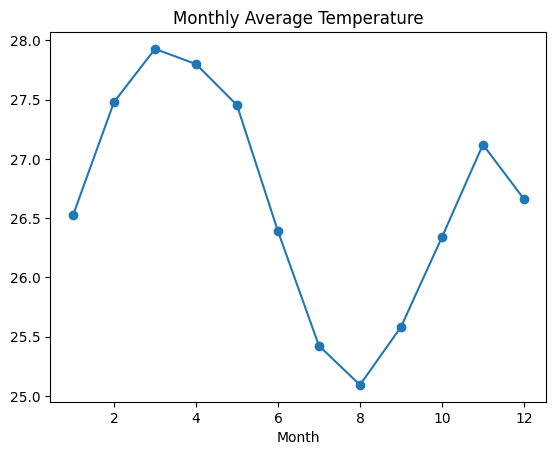

In [17]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(kind="line", marker="o")
plt.title("Monthly Average Temperature")
plt.show()

In [18]:
monthly_temp.idxmax(), monthly_temp.max()
monthly_temp.idxmin(), monthly_temp.min()

(8, 25.09369501466276)

Rainfall Trend

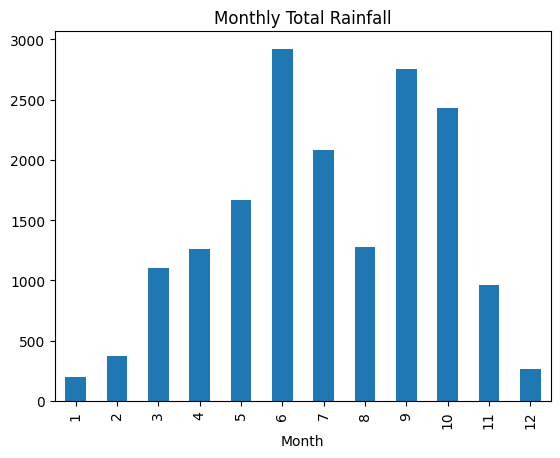

In [19]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall")
plt.show()

Correlation Analysis

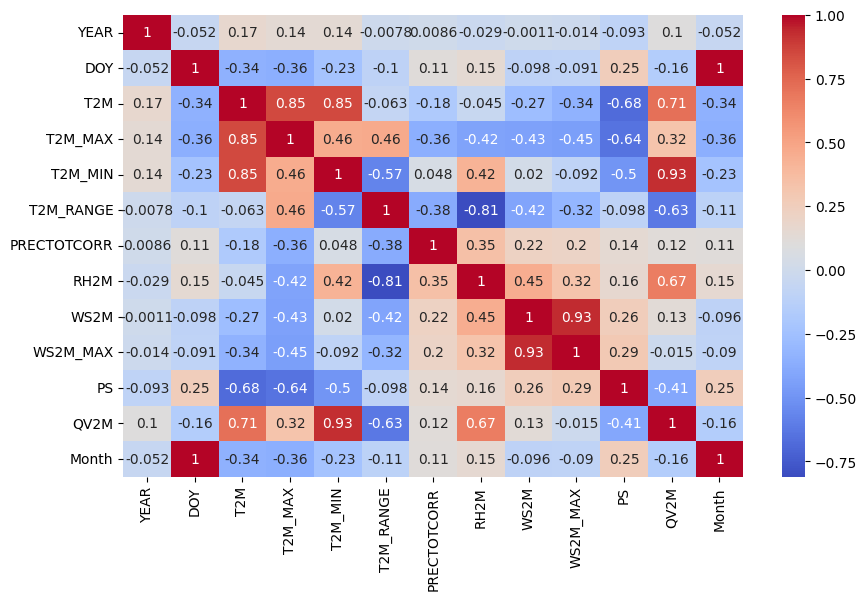

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

Scatter plots

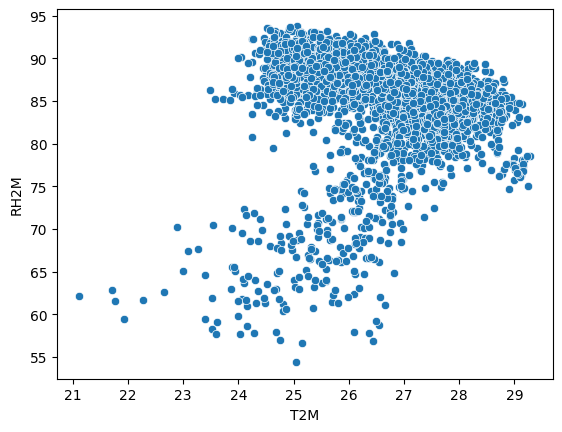

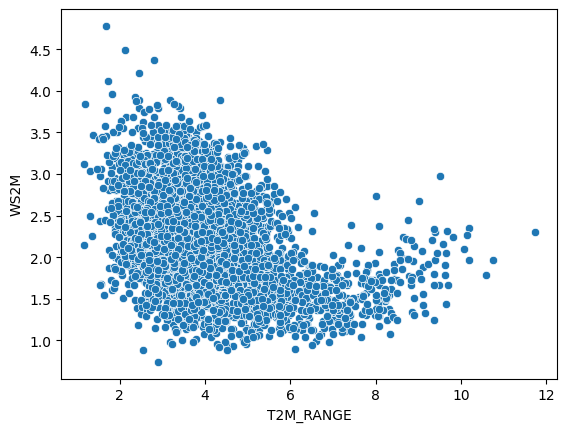

In [21]:
sns.scatterplot(x=df["T2M"], y=df["RH2M"])
plt.show()

df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

sns.scatterplot(x=df["T2M_RANGE"], y=df["WS2M"])
plt.show()

Distribution Analysis

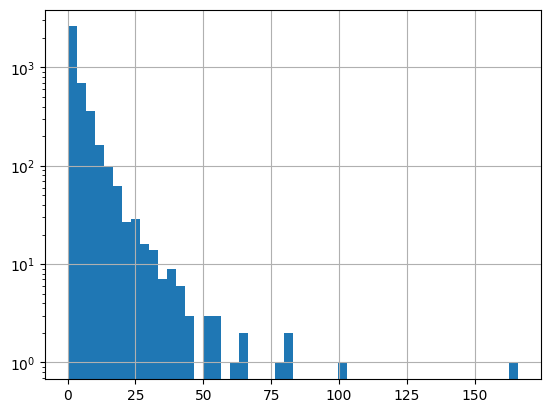

In [22]:
df["PRECTOTCORR"].hist(bins=50)
plt.yscale("log")  # if skewed
plt.show()

Bubble Chart

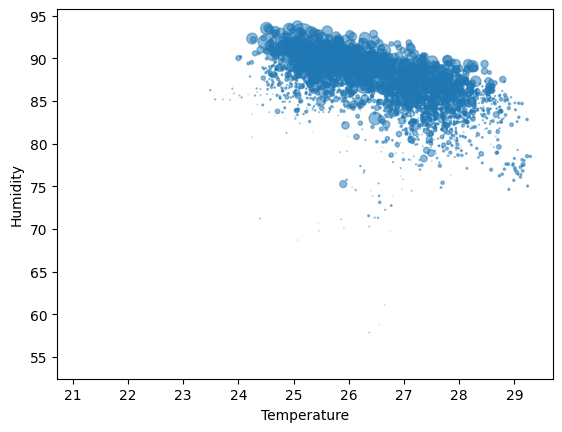

In [23]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"]*2,
    alpha=0.5
)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()